# Mall Customer Segmentation Using Clustering

## K-Means, Agglomerative Hierarchical Clustering and DBSCAN

This notebook develops an unsupervised learning workflow for customer segmentation using the **Mall Customers** dataset.

The analysis covers:
- Exploratory Data Analysis (EDA)
- Feature selection and scaling
- K-Means clustering
- Agglomerative Hierarchical Clustering
- DBSCAN
- Silhouette Score, Calinski-Harabasz Index and Davies-Bouldin Index
- Visual comparison of clustering metrics
- A second clustering experiment using the **Iris dataset**

### Assignment objectives
1. Perform EDA and explain the main findings.
2. Apply K-Means, Agglomerative Clustering and DBSCAN.
3. Compare clustering quality using multiple evaluation metrics.
4. Visualise the metric comparison and discuss the results.
5. Repeat the clustering techniques on another dataset and present findings.

## 1. Import libraries

The imports include tools for data analysis, visualisation, scaling, clustering, hierarchical dendrograms and internal clustering evaluation.

The original notebook already imported most required packages. The revised version also adds utilities that make metric evaluation safe when DBSCAN produces noise points or too few clusters.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load the Mall Customers dataset

The original notebook used `pd.read_csv('Mall_Customers.csv')`, which works only when the CSV is in the notebook's current working directory.

For a GitHub project, the data path is made explicit:

`../data/Mall_Customers.csv`

**Place the supplied `Mall_Customers.csv` file inside the repository's `data` folder before running this section.**

In [ ]:
DATA_PATH = "/Users/theabood/Desktop/mall-customer-clustering-repository/data/Mall_Customers.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        "Mall_Customers.csv was not found. "
        "Place the dataset in the repository's data/ folder."
    )

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Initial data inspection

We first inspect the column names, data types, missing values and duplicates. This prevents us from applying clustering to incorrectly formatted or incomplete data.

In [ ]:
print("Column information:")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
}))

print("Duplicate rows:", df.duplicated().sum())

Column information:


,dtype,missing,unique
CustomerID,int64,0,200
Gender,object,0,2
Age,int64,0,51
Annual Income (k$),int64,0,64
Spending Score (1-100),int64,0,84


Duplicate rows: 0


## 4. Data cleaning and preprocessing

`CustomerID` is an identifier rather than a behavioural feature, so it is not useful for customer segmentation and is excluded.

`Gender` is categorical. For the clustering experiment we encode it numerically, although the main clustering analysis follows the original notebook and focuses on:

- Age
- Annual Income (k$)
- Spending Score (1-100)

This keeps the clustering interpretation straightforward.

In [ ]:
df = df.drop_duplicates().copy()

if "CustomerID" in df.columns:
    df = df.drop(columns=["CustomerID"])

if "Gender" in df.columns and df["Gender"].dtype == "object":
    gender_map = {"Male": 0, "Female": 1}
    df["Gender"] = df["Gender"].map(gender_map)

print("Shape after cleaning:", df.shape)
display(df.head())

Shape after cleaning: (200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## 5. Exploratory Data Analysis

EDA is especially important in clustering because there is no labelled target variable telling us what the correct groups should be.

We examine:
- Summary statistics
- Distributions
- Relationships between the selected segmentation variables
- Correlations
- Potential outliers

The purpose is to understand the structure that the clustering algorithms will attempt to discover.

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Gender,200.0,0.56,0.497633,0.0,0.00,1.0,1.0,1.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


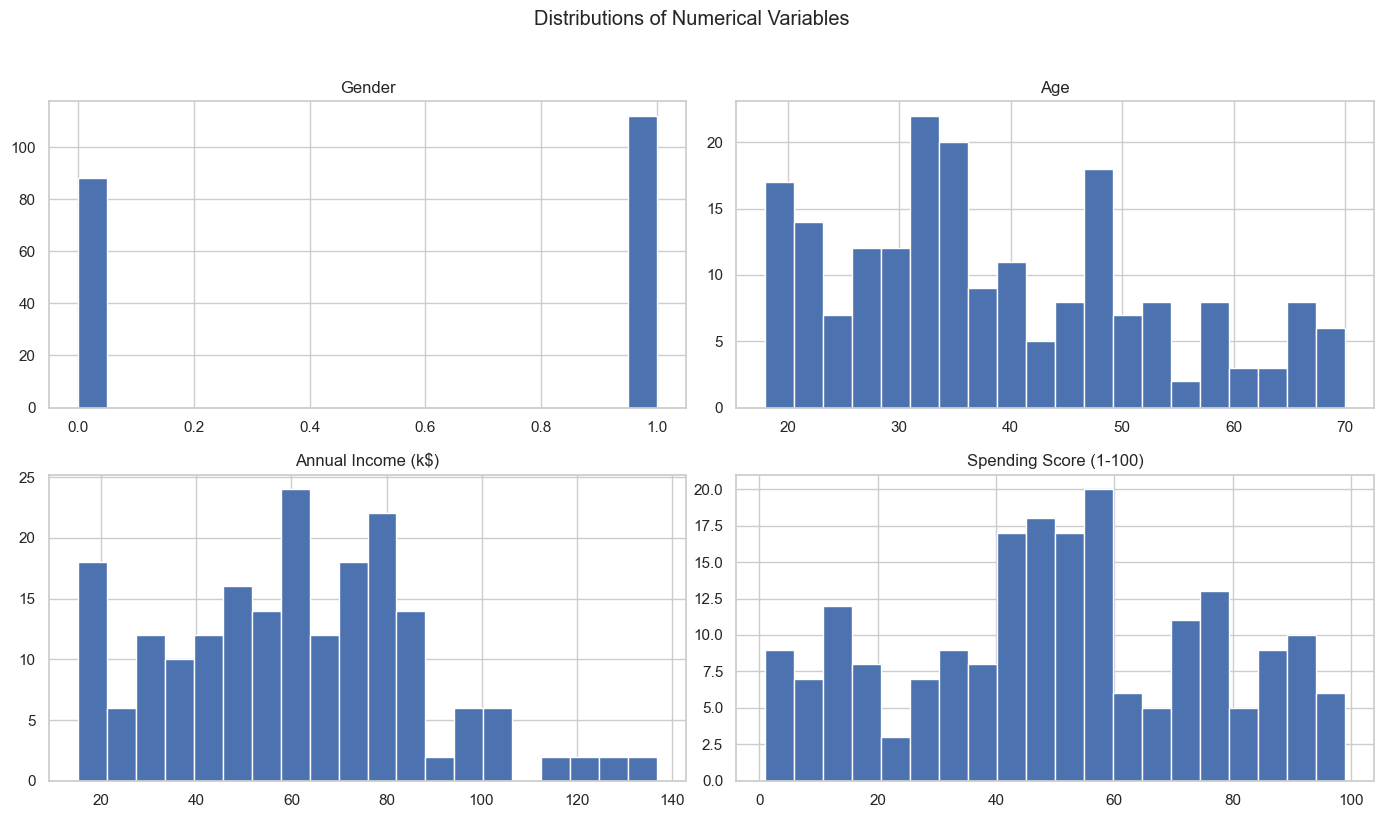

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(figsize=(14, 8), bins=20)
plt.suptitle("Distributions of Numerical Variables", y=1.02)
plt.tight_layout()
plt.show()

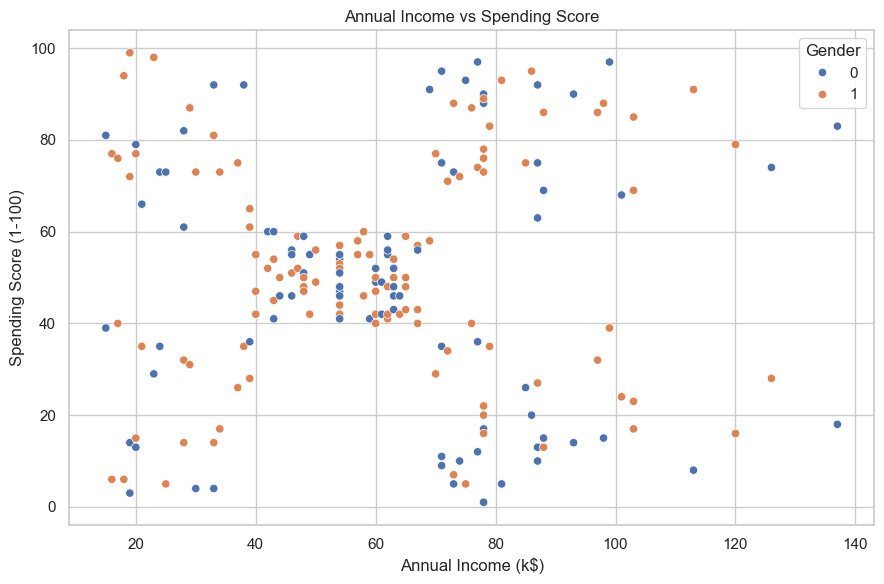

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender" if "Gender" in df.columns else None
)
plt.title("Annual Income vs Spending Score")
plt.tight_layout()
plt.show()

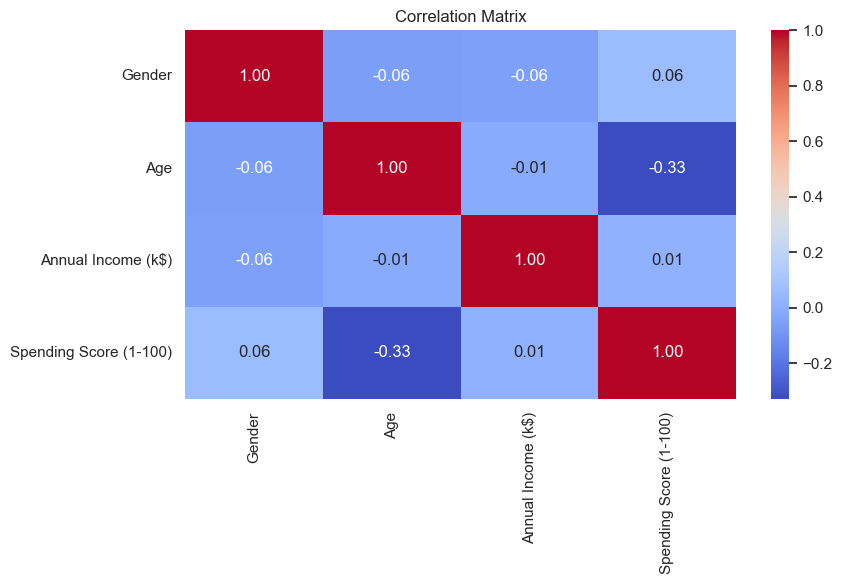

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### EDA findings

The numerical summaries and plots should be read as evidence about the dataset's structure rather than as a prediction problem.

The most useful segmentation variables in this exercise are **annual income** and **spending score** because their scatter plot can reveal groups of customers with different purchasing behaviour. Age adds another dimension that can refine those groups.

Clustering does not require a target label: the algorithms search for structure based on similarity between observations.

## 6. Select features and scale them

We use the same three features as the original notebook:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

Scaling is necessary because these variables are measured on different numerical ranges. Without scaling, a feature with a larger numerical range could have disproportionate influence on distance-based algorithms such as K-Means and DBSCAN.

In [ ]:
feature_cols = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used for clustering:", feature_cols)
print("Scaled matrix shape:", X_scaled.shape)

Features used for clustering: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Scaled matrix shape: (200, 3)


## 7. K-Means Clustering

K-Means partitions observations into a predefined number of clusters by repeatedly:

1. Assigning each point to the nearest centroid.
2. Recalculating the centroid of each cluster.
3. Repeating until the assignments stabilise.

The original notebook uses **K = 5**, so that configuration is retained here.

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster counts:")
display(df["KMeans_Cluster"].value_counts().sort_index())

K-Means cluster counts:


KMeans_Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

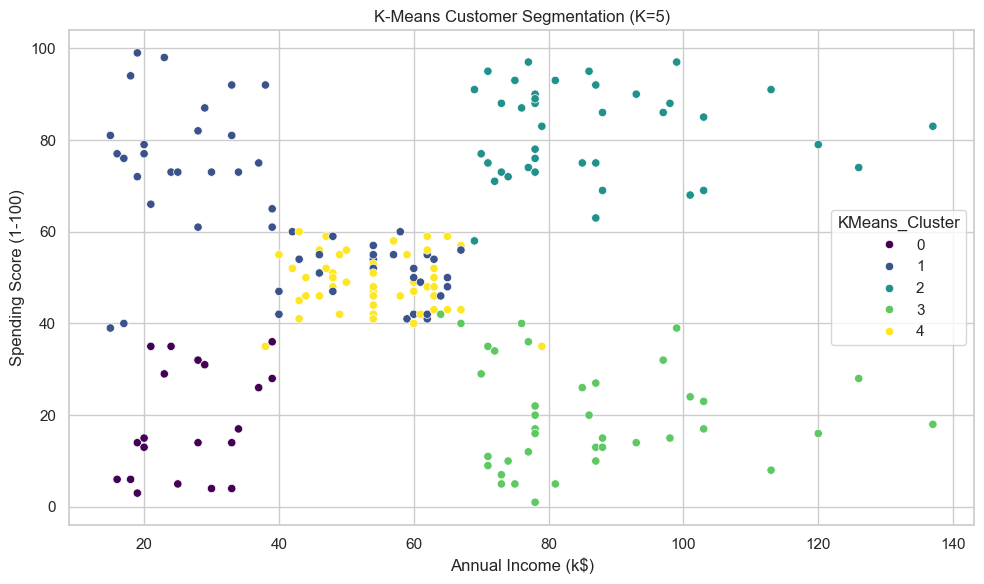

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="KMeans_Cluster",
    palette="viridis"
)
plt.title("K-Means Customer Segmentation (K=5)")
plt.tight_layout()
plt.show()

## 8. Agglomerative Hierarchical Clustering

Agglomerative clustering starts with every observation as its own cluster and progressively merges the closest groups until the desired number of clusters remains.

The dendrogram below shows the hierarchy of those merges. The original analysis uses Ward linkage and five final clusters.

In [ ]:
agglo = AgglomerativeClustering(n_clusters=5, linkage="ward")
agglo_labels = agglo.fit_predict(X_scaled)
df["Agglo_Cluster"] = agglo_labels

print("Agglomerative cluster counts:")
display(df["Agglo_Cluster"].value_counts().sort_index())

Agglomerative cluster counts:


Agglo_Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64

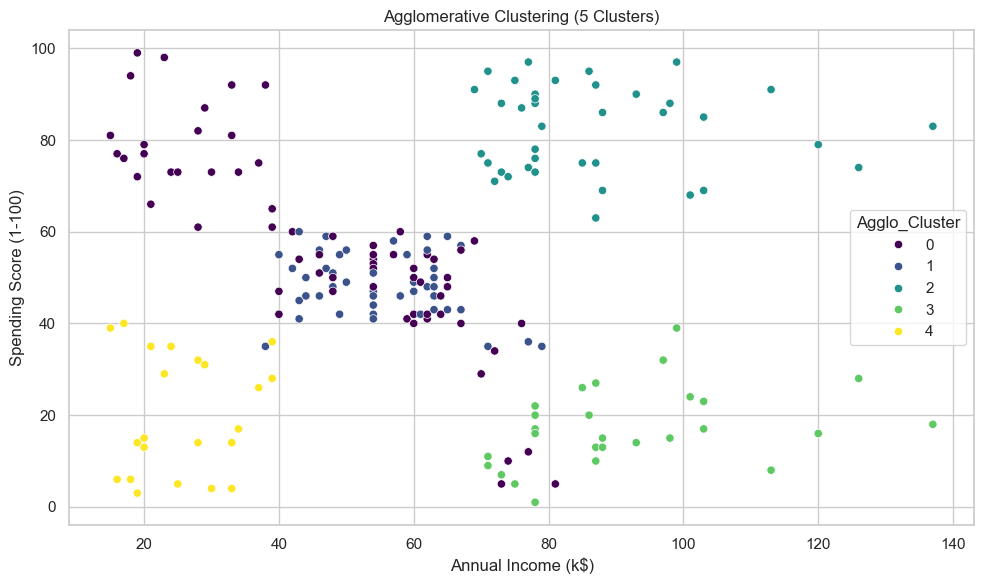

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Agglo_Cluster",
    palette="viridis"
)
plt.title("Agglomerative Clustering (5 Clusters)")
plt.tight_layout()
plt.show()

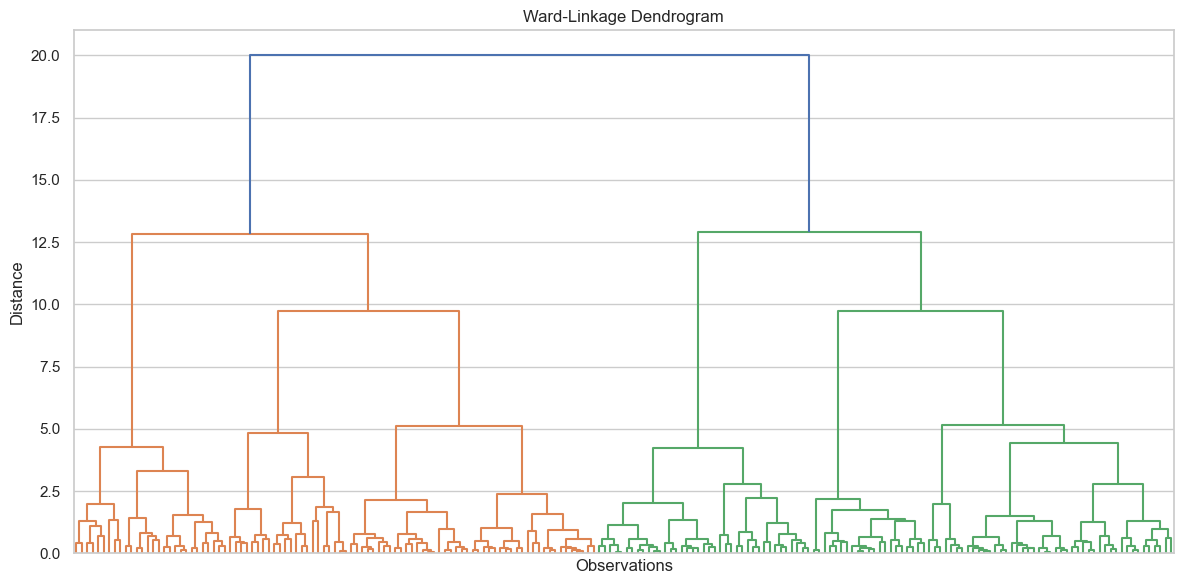

In [ ]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, no_labels=True)
plt.title("Ward-Linkage Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 9. DBSCAN

DBSCAN is density-based rather than centroid-based. It identifies dense regions as clusters and can label isolated observations as **noise (`-1`)**.

The original notebook uses:
- `eps = 0.5`
- `min_samples = 5`

Unlike K-Means and Agglomerative Clustering, DBSCAN does not require the number of clusters to be specified in advance.

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN label counts:")
display(df["DBSCAN_Cluster"].value_counts().sort_index())
print("Number of clusters excluding noise:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise observations:", np.sum(dbscan_labels == -1))

DBSCAN label counts:


DBSCAN_Cluster
-1    60
 0    17
 1     5
 2    51
 3    28
 4    32
 5     7
Name: count, dtype: int64

Number of clusters excluding noise: 6
Number of noise observations: 60


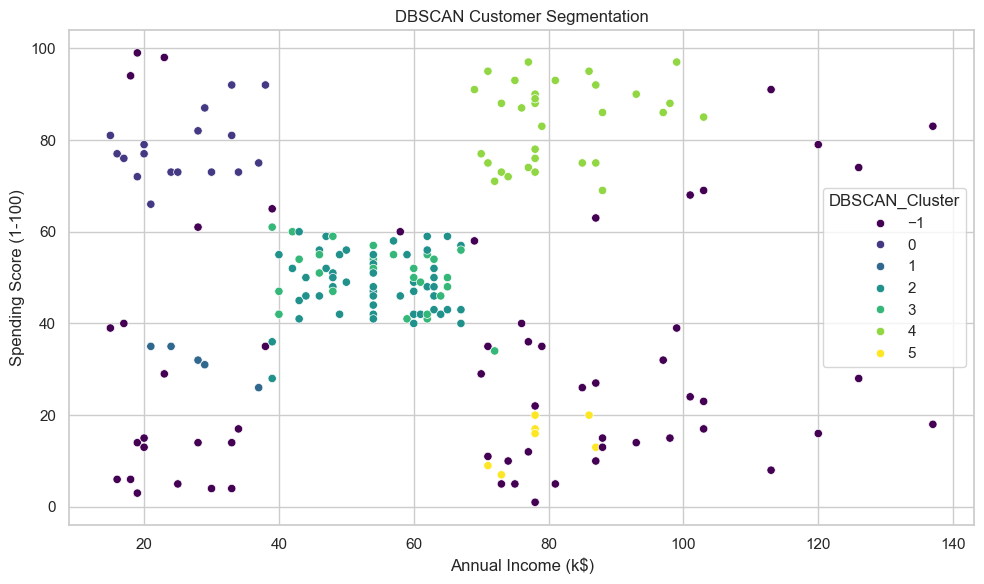

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN_Cluster",
    palette="viridis"
)
plt.title("DBSCAN Customer Segmentation")
plt.tight_layout()
plt.show()

## 10. Clustering evaluation metrics

Because this is unsupervised learning, there is no ground-truth target in the Mall Customers dataset. We therefore use internal validation metrics:

- **Silhouette Score:** higher is better; measures how well each point fits its own cluster compared with neighbouring clusters.
- **Calinski-Harabasz Index:** higher is better; rewards compact, well-separated clusters.
- **Davies-Bouldin Index:** lower is better; evaluates average similarity between each cluster and its most similar alternative cluster.

For DBSCAN, noise points are excluded from the metric calculation where possible. This avoids treating the noise label as a normal cluster.

In [ ]:
def clustering_metrics(X_data, labels, ignore_noise=False):
    labels = np.asarray(labels)

    if ignore_noise and -1 in labels:
        mask = labels != -1
        X_eval = X_data[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_data
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))

    if n_clusters < 2 or n_clusters >= len(labels_eval):
        return {
            "Silhouette": np.nan,
            "Calinski-Harabasz": np.nan,
            "Davies-Bouldin": np.nan
        }

    return {
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Calinski-Harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "Davies-Bouldin": davies_bouldin_score(X_eval, labels_eval)
    }

mall_metrics = pd.DataFrame({
    "K-Means": clustering_metrics(X_scaled, kmeans_labels),
    "Agglomerative": clustering_metrics(X_scaled, agglo_labels),
    "DBSCAN": clustering_metrics(X_scaled, dbscan_labels, ignore_noise=True)
}).T

display(mall_metrics.round(4))

,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means,0.4166,125.1009,0.8746
Agglomerative,0.3900,107.8266,0.9163
DBSCAN,0.4817,117.8049,0.6386


## 11. Visual comparison of clustering metrics

A visual comparison makes it easier to see which method performs best under each metric.

Remember the direction of each metric:
- Silhouette: **higher is better**
- Calinski-Harabasz: **higher is better**
- Davies-Bouldin: **lower is better**

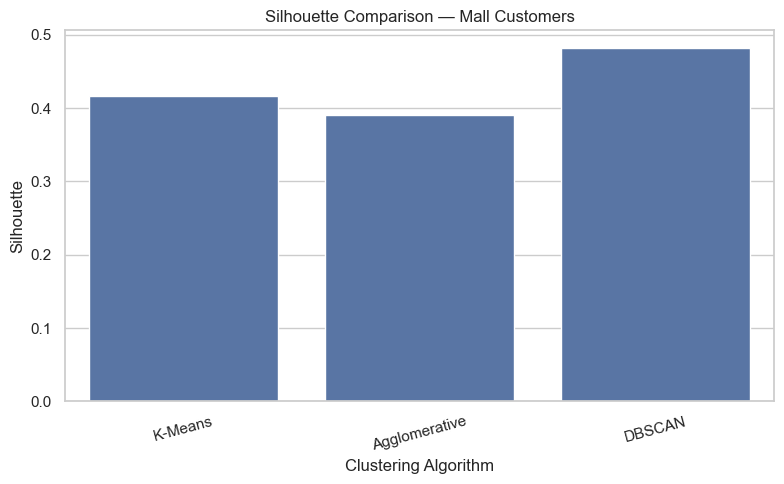

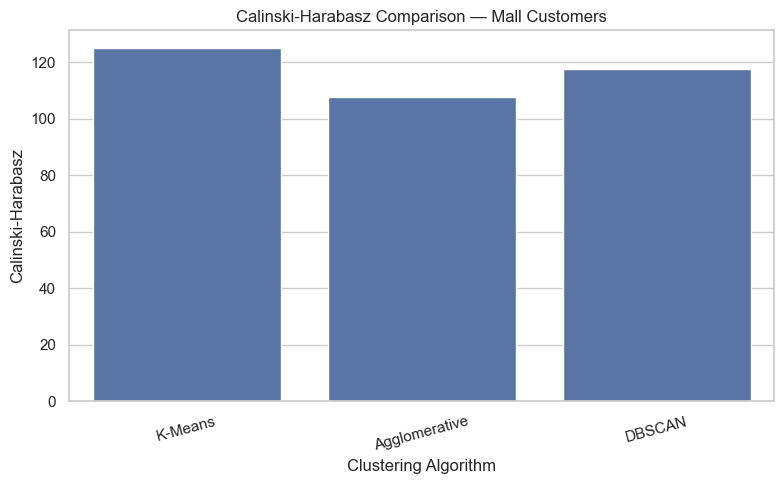

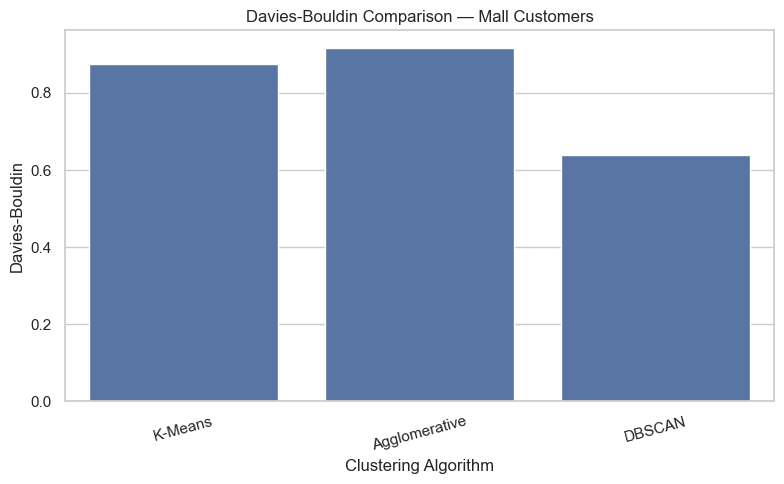

In [ ]:
for metric in ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=mall_metrics.index,
        y=mall_metrics[metric].values
    )
    plt.title(f"{metric} Comparison — Mall Customers")
    plt.xlabel("Clustering Algorithm")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

### Discussion of the Mall Customers results

Use the three charts together rather than selecting a model from one metric alone.

A strong clustering solution should generally have a relatively high Silhouette Score and Calinski-Harabasz Index while maintaining a low Davies-Bouldin Index. DBSCAN should also be considered in light of how many observations it labels as noise.

Because the algorithms use different clustering principles, disagreement between metrics is possible. The final choice should therefore combine numerical scores with the cluster visualisations and the practical interpretability of the customer segments.

# 12. Clustering another dataset

To complete the task without introducing an external download dependency, we use the classic **Iris dataset** included in scikit-learn.

The dataset contains four measurements:
- Sepal length
- Sepal width
- Petal length
- Petal width

The species labels are deliberately not used for clustering. This keeps the experiment unsupervised. The labels are only available as an optional reference after clustering if one wants to discuss how well the discovered structure corresponds to the known species.

In [ ]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

X_iris = iris_df[iris.feature_names].copy()

iris_scaler = StandardScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

print("Iris dataset shape:", X_iris.shape)
display(X_iris.head())

Iris dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 13. Iris EDA

Before clustering the second dataset, we briefly inspect the feature distributions and relationships.

In [ ]:
display(X_iris.describe().T)

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


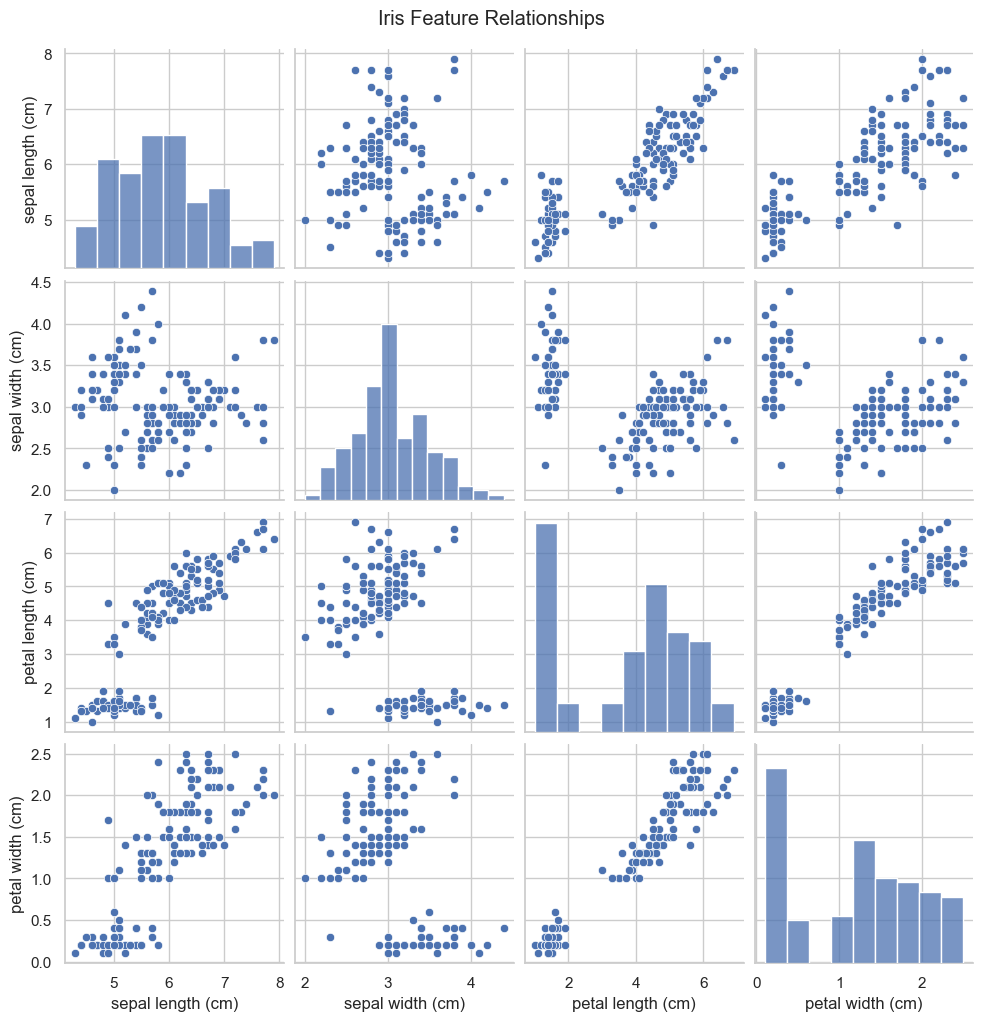

In [ ]:
sns.pairplot(
    pd.DataFrame(X_iris, columns=iris.feature_names),
    diag_kind="hist"
)
plt.suptitle("Iris Feature Relationships", y=1.02)
plt.show()

## 14. Apply the three clustering techniques to Iris

For comparability, K-Means and Agglomerative Clustering again use three clusters. DBSCAN keeps its density-based approach and uses parameters appropriate for the standardised Iris feature space.

In [ ]:
iris_kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)
iris_kmeans_labels = iris_kmeans.fit_predict(X_iris_scaled)

iris_agglo = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
iris_agglo_labels = iris_agglo.fit_predict(X_iris_scaled)

iris_dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)
iris_dbscan_labels = iris_dbscan.fit_predict(X_iris_scaled)

iris_labels = {
    "K-Means": iris_kmeans_labels,
    "Agglomerative": iris_agglo_labels,
    "DBSCAN": iris_dbscan_labels
}

for name, labels in iris_labels.items():
    print(name, "cluster counts:")
    print(pd.Series(labels).value_counts().sort_index().to_dict())

K-Means cluster counts:
{0: 53, 1: 50, 2: 47}
Agglomerative cluster counts:
{0: 71, 1: 49, 2: 30}
DBSCAN cluster counts:
{-1: 4, 0: 49, 1: 97}


## 15. Visualise Iris clustering

The Iris dataset has four dimensions, so the plots below use the two petal measurements, which are useful for visually inspecting the separation found by the clustering methods.

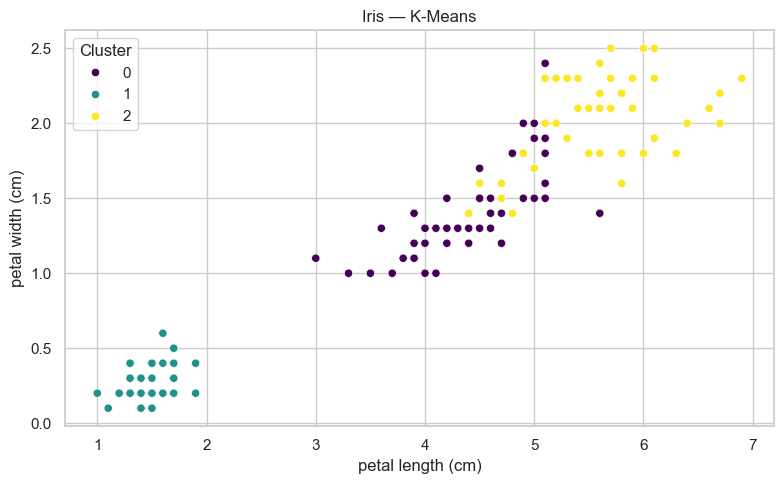

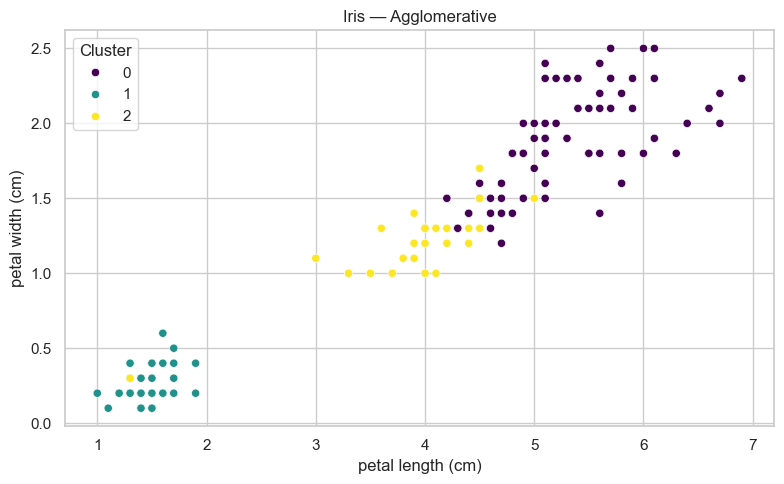

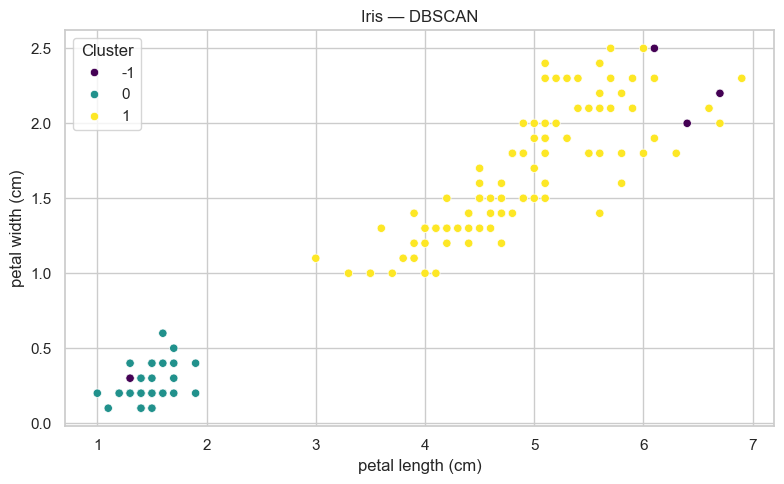

In [ ]:
iris_plot_df = pd.DataFrame(X_iris, columns=iris.feature_names)

for name, labels in iris_labels.items():
    plot_df = iris_plot_df.copy()
    plot_df["Cluster"] = labels

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=plot_df,
        x="petal length (cm)",
        y="petal width (cm)",
        hue="Cluster",
        palette="viridis"
    )
    plt.title(f"Iris — {name}")
    plt.tight_layout()
    plt.show()

## 16. Evaluate the Iris clustering results

In [ ]:
iris_metrics = pd.DataFrame({
    name: clustering_metrics(
        X_iris_scaled,
        labels,
        ignore_noise=(name == "DBSCAN")
    )
    for name, labels in iris_labels.items()
}).T

display(iris_metrics.round(4))

,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means,0.4599,241.9044,0.8336
Agglomerative,0.4467,222.7192,0.8035
DBSCAN,0.5979,277.6510,0.5688


## 17. Visual comparison of Iris metrics

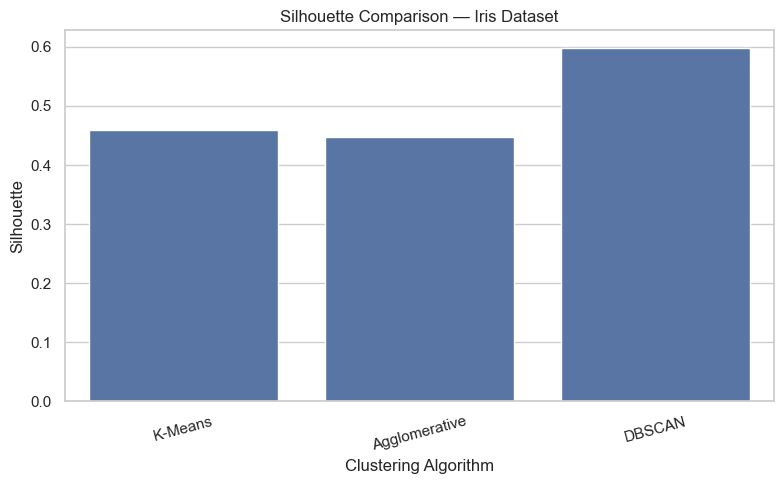

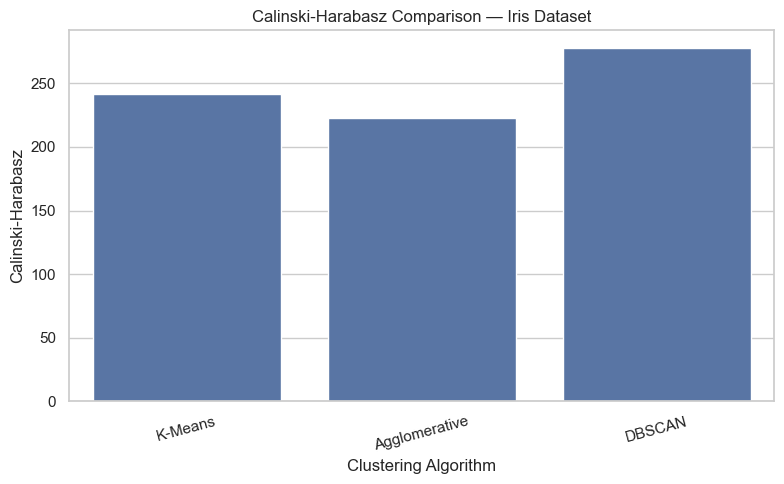

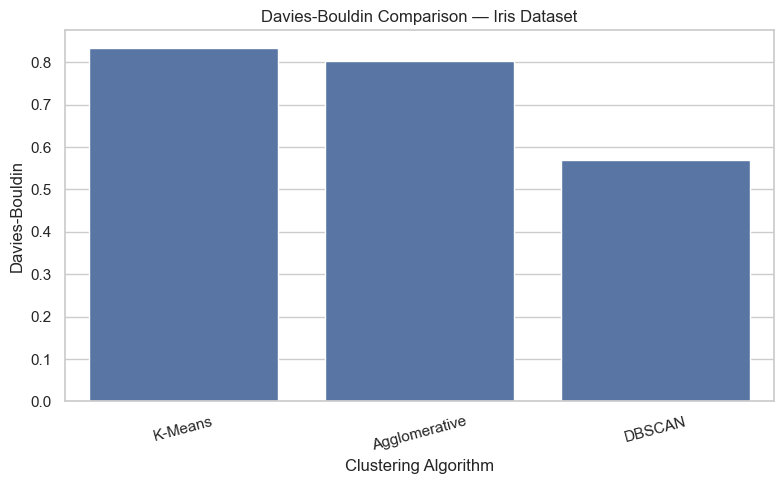

In [ ]:
for metric in ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=iris_metrics.index,
        y=iris_metrics[metric].values
    )
    plt.title(f"{metric} Comparison — Iris Dataset")
    plt.xlabel("Clustering Algorithm")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 18. Optional reference: compare clusters with known Iris species

The following table is **not used to train the clustering algorithms**. It is a post-hoc reference because the Iris dataset happens to provide species labels.

The contingency tables show how cluster assignments correspond to the known species. Cluster IDs themselves have no intrinsic meaning, so we do not expect cluster `0` to automatically represent a particular species.

In [26]:
species = pd.Series(iris.target_names[iris.target], name="Species")

for name, labels in iris_labels.items():
    contingency = pd.crosstab(species, pd.Series(labels, name="Cluster"))
    print(f"\n{name}")
    display(contingency)


K-Means


Cluster,0,1,2
Species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36



Agglomerative


Cluster,0,1,2
Species,,,
setosa,0,49,1
versicolor,23,0,27
virginica,48,0,2



DBSCAN


Cluster,-1,0,1
Species,,,
setosa,1,49,0
versicolor,0,0,50
virginica,3,0,47


## 19. Final findings

### Mall Customers
The best clustering method should be identified from the generated metric table and plots. Higher Silhouette and Calinski-Harabasz scores indicate stronger compactness/separation, while a lower Davies-Bouldin score is preferable. DBSCAN should additionally be judged by its noise proportion and whether the resulting groups are practically meaningful.

### Iris
Iris has a comparatively well-structured feature space, especially because petal measurements separate the species strongly. K-Means and Agglomerative Clustering can therefore reveal meaningful groups without using the species labels. DBSCAN may behave differently depending on its density parameters and can mark boundary observations as noise.

### Overall lesson
No single clustering algorithm is universally best. K-Means is simple and effective when clusters are roughly compact and the number of groups is known. Agglomerative clustering provides a useful hierarchy and dendrogram. DBSCAN is valuable when clusters are density-based and noise detection matters.